# 1. Generar conjunto de datos sintéticos

Cargar la matriz de correlación

In [1]:
import numpy as np
import pandas as pd

cov_matrix = pd.read_csv('mat_cov.csv').values

In [2]:
np.random.seed(42)

n_samples = 150
n_features = 50

mean = np.zeros(n_features)

# Generar datos sintéticos
X = np.random.multivariate_normal(mean, cov_matrix, size=n_samples)

# Convertir a DataFrame
X_df = pd.DataFrame(X, columns=[f'X{i+1}' for i in range(n_features)])

In [15]:
X_df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X41,X42,X43,X44,X45,X46,X47,X48,X49,X50
0,0.186308,-0.820221,0.422954,0.190821,-1.320801,-0.454796,0.804937,-1.703741,-0.353018,0.103973,...,-0.361749,0.678168,0.289063,-0.463401,-0.146830,-0.146265,1.055668,-0.172807,-0.155737,1.221115
1,0.918081,0.025233,-0.178135,-0.653559,-0.742937,-0.724692,0.592756,0.361891,0.816047,0.347074,...,0.400291,0.046623,0.095804,-0.347168,0.189116,1.255416,-0.712092,-0.358778,0.000080,0.678081
2,-0.943178,-0.355982,-1.254916,0.594678,0.496199,-0.462866,-0.215763,1.047683,-0.133262,0.646307,...,-0.653090,1.054205,0.980147,-0.120957,-0.402486,-1.335639,-1.279100,0.495933,0.321842,-0.505359
3,0.187396,-0.260711,-0.647634,-0.088311,-0.404784,-0.364406,0.354536,0.489012,-0.413760,-1.125269,...,-0.449818,1.208946,-1.079749,-0.031084,1.052038,0.965266,-0.297255,0.414274,-0.138381,0.552097
4,-0.165754,-0.010144,0.395370,0.103226,0.121329,0.070942,1.224411,-0.745223,-0.083532,0.851168,...,-0.494927,1.737413,-0.203094,-1.131112,1.543805,0.142476,0.773700,0.760420,-0.345862,-0.146012


# 2. Definir una variable objetivo Y

In [4]:
np.random.seed(42)
n_informativas = 5
n_variables = X.shape[1]

# Índices de las variables informativas
informativas_idx = np.random.choice(n_variables, n_informativas, replace=False)

coeficientes = np.zeros(n_variables)
coeficientes[informativas_idx] = np.random.uniform(1, 5, size=n_informativas)

# Generar Y como combinación lineal + ruido gaussiano
ruido = np.random.normal(loc=0, scale=0.25, size=X.shape[0])
Y = X @ coeficientes + ruido

# 3. Separar los datos

* Conjunto de entrenamiento: 100 observaciones 
* Conjunto de test: 50 observaciones 

In [5]:
X_train = X[:100]
y_train = Y[:100]

X_test = X[100:]
y_test = Y[100:]

# 4. Entrenamientro de modelos

In [6]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Regresión Lineal

In [7]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
coef_lr = modelo_lr.coef_

## Regresión Ridge

In [8]:
modelo_ridge = Ridge(alpha=1.0)
modelo_ridge.fit(X_train, y_train)
coef_ridge = modelo_ridge.coef_

## Regresión Bayesiana

In [9]:
theta = (np.linalg.inv(X.T @ X)) @ (X.T @ y_train)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 100 is different from 150)

In [ ]:
y_pred = X @ theta

mse = np.mean((y_train-y_pred)**2)

sigma2 = mse

# 5. Análisis de componentes principales (PCA)

Se procede a trabajar con PCA estandarizado sobre el conjunto de entrenamiento, para ello se estandarizan nuestros datos ya que PCA es sensible a la escala de los datos (recae en distancias euclidianas).

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [11]:
# Se estandarizan los valores de las variables observadas para el PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)


La idea es proyectar sobre las dos componentes principales.

In [13]:
# PCA sobre las dos principales componentes 
pca = PCA(n_components=2)
pca.fit(X_train_scaled)
X_pca = pca.transform(X_train_scaled)
print(X_pca.shape)

(100, 2)


Luego graficamos las observaciones proyectadas:

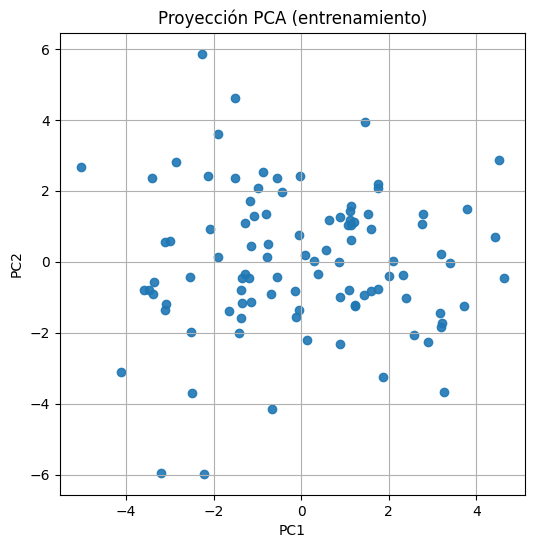

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.9)
plt.title("Proyección PCA (entrenamiento)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# 6. Generación de datos de una distribución desplazada

Particionamos el conjunto de testing en dos subconjuntos: uno con la distribucion original y otro desplazado.

In [ ]:
X_test_A = X_test[:25].copy()
X_test_B = X_test[25:].copy()

Luego generamos un desplazamiento aleatoreo a cada observacion (fila)

In [ ]:
shift = np.random.uniform(-10, 10, size=50)
X_test_A_shifted = X_test_A + shift

# 7. prediccion en ambos conjuntos de testing

Para esta seccion, se predice sobre ambos conjunto de testing la salida correspondiente y se evalua el desempeno del modelo con respecto a la metrica de error para ambos conjuntos.